In [1]:
import sys
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt
import pickle
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *

def plot_two_var(results, x, y):
    fig, ax = plt.subplots()
    for dataset_name, data_group in results.groupby("dataset"):
        xs = data_group[x]
        ys = data_group[y]
        ax.plot(xs, ys, label=dataset_name, marker="o")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()
    plt.show()

def construct_dataset(dataset_name, num_estimators, num_features):
    path = '../datasets/{}.csv'.format(dataset_name)
    dataset = pd.read_csv(path)

    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, num_estimators)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]
    header = pd.Index(["intercept"] + list(X.columns)).astype("object")
    X_one_hot, y = utils.get_X_y(X, y)

    assert len(header) == num_features

    return X_one_hot, y, header

def plot_diversity_correlation(results, x):
    results["diversity_correlation"] = results.apply(
        lambda row: average_pairwise_diversity(
            row["betas"], 
            correlation, 
            50, 
            construct_dataset(row["dataset"], row["num_estimators"], row["num_features"])[0]
        ), axis=1
    )
    plot_two_var(results, x, "diversity_correlation")

### Comparing Order Bias

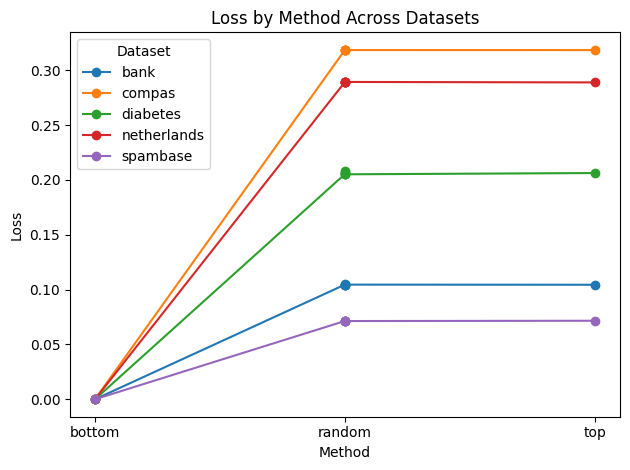

In [8]:
with open("results/order.pkl", "rb") as f:
    results = pickle.load(f)

results = pd.DataFrame(results)

x_order = ["bottom", "random", "top"]
fig, ax = plt.subplots()
for dataset_name, values in results.groupby("dataset"):
    sorted_vals = values.sort_values(by="feature_selection")
    xs = sorted_vals["feature_selection"]
    ys = sorted_vals["loss"]
    ax.plot(xs, ys, marker='o', label=dataset_name)

# Format x-axis
ax.set_xticks(range(3))
ax.set_xticklabels(x_order)
ax.set_xlabel("Method")
ax.set_ylabel("Loss")
ax.legend(title="Dataset")
ax.set_title("Loss by Method Across Datasets")

plt.tight_layout()
plt.show()

### Number of Features

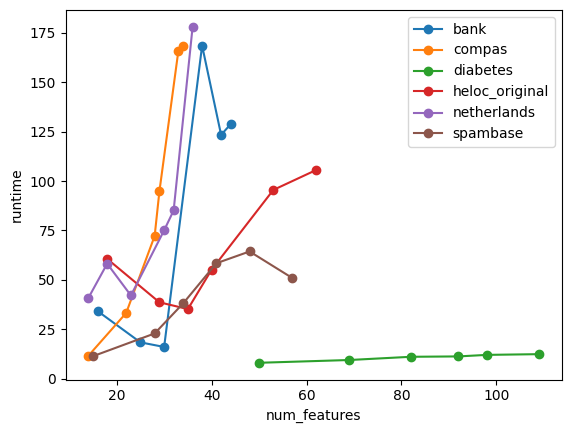

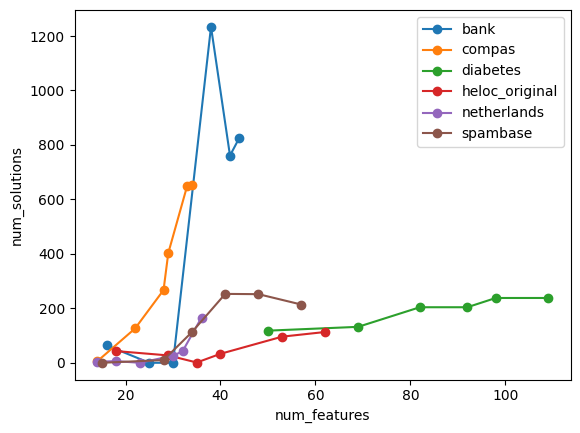

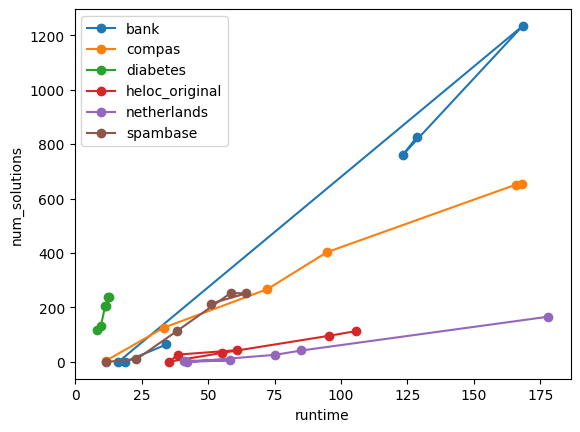

In [9]:
with open(f"results/features.pkl", "rb") as f:
    results = pickle.load(f)
results = pd.DataFrame(results)

plot_two_var(results, "num_features", "runtime")
plot_two_var(results, "num_features", "num_solutions")
plot_two_var(results, "runtime", "num_solutions")

### Gap Tolerance

In [2]:
def plot_gap_tolerance(file_name):
    with open(f"results/{file_name}.pkl", "rb") as f:
        results = pickle.load(f)
    results = pd.DataFrame(results)

    plot_two_var(results, "gap_tolerance", "num_solutions")
    plot_two_var(results, "gap_tolerance", "runtime")
    plot_two_var(results, "num_solutions", "runtime")
    plot_two_var(results, "gap_tolerance", "loss")

    for diversity_fnc in [intersection_over_union, euclidean_distance, cosine_similarity]:
        col_name = f"diversity_{diversity_fnc.__name__}"
        results[col_name] = results["betas"].apply(lambda betas: average_pairwise_diversity(betas, diversity_fnc, 50))
        plot_two_var(results, "gap_tolerance", col_name)
    
    plot_diversity_correlation(results, "gap_tolerance")

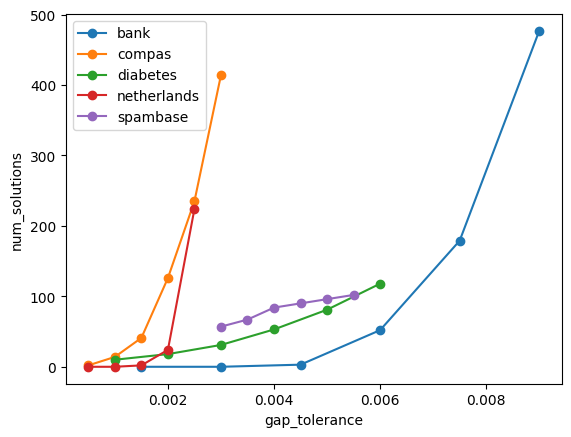

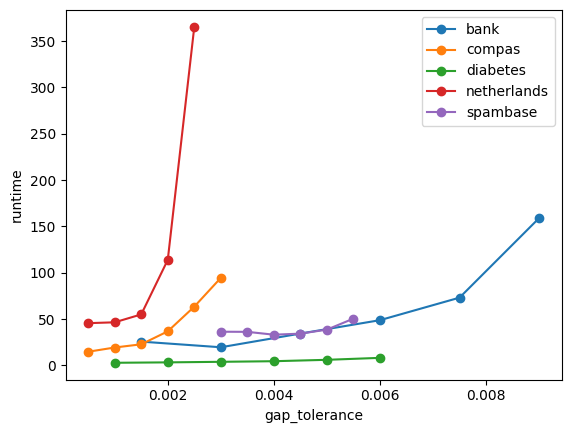

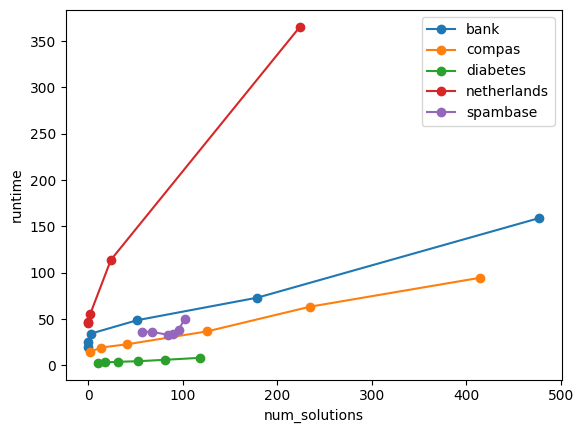

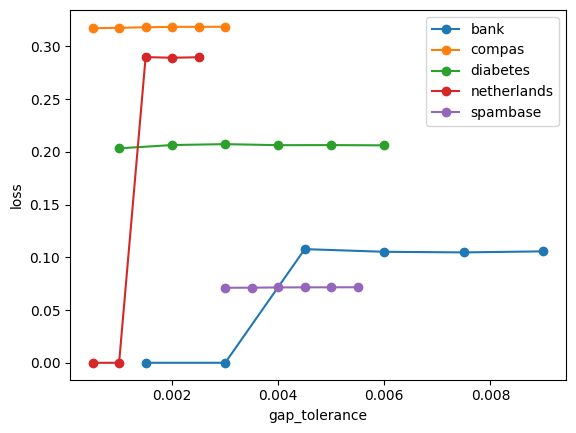

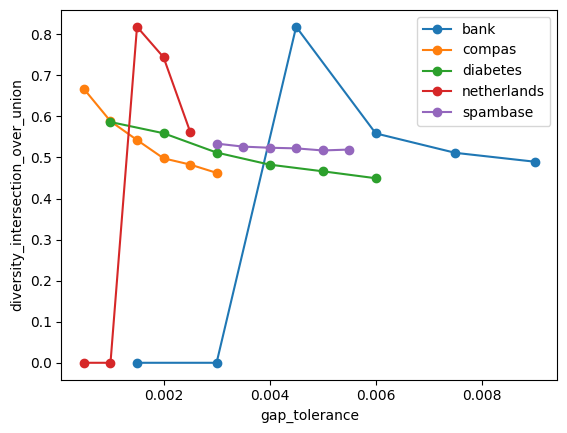

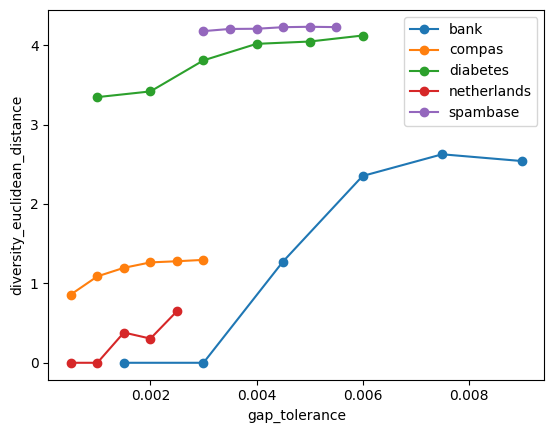

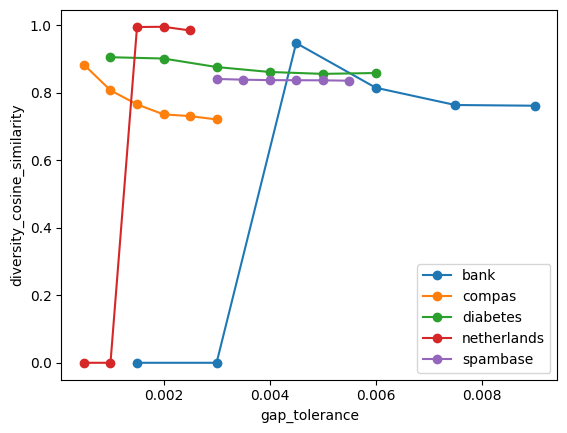

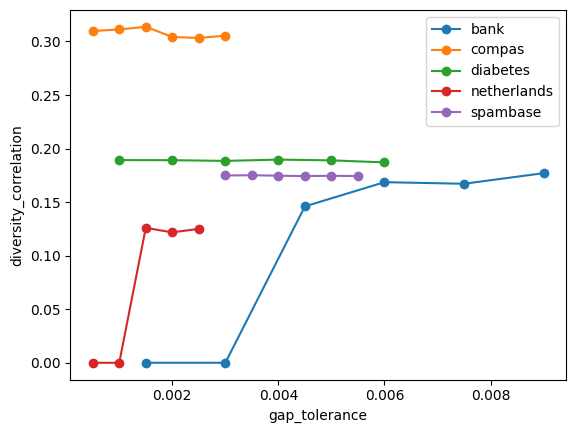

In [12]:
plot_gap_tolerance("tolerance")

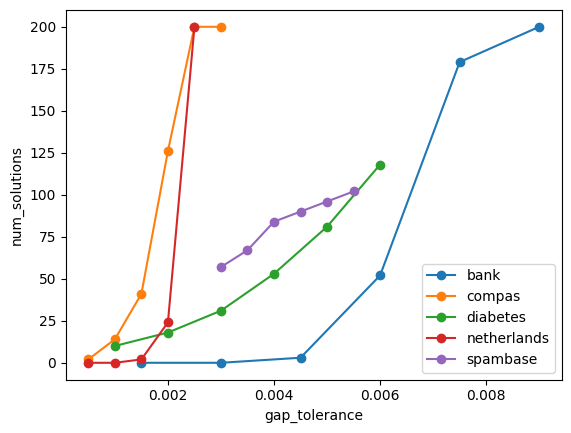

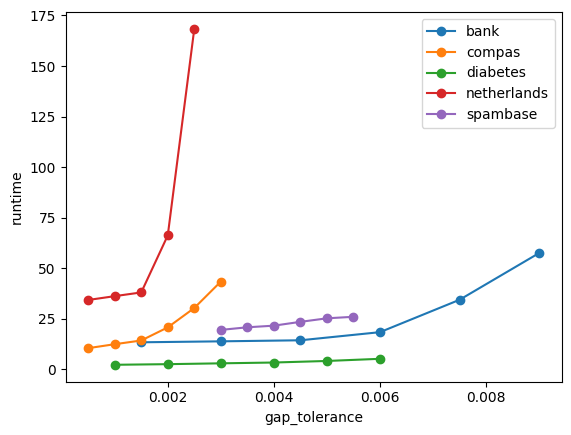

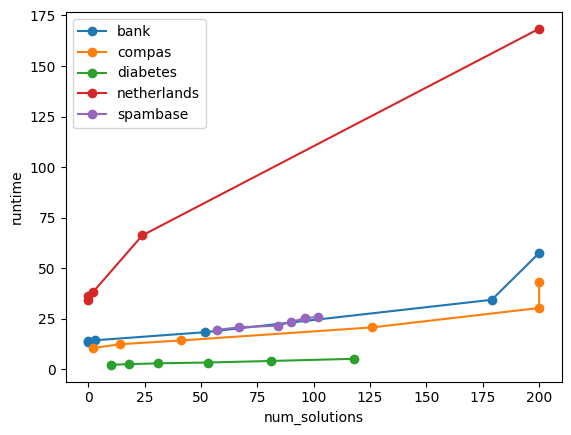

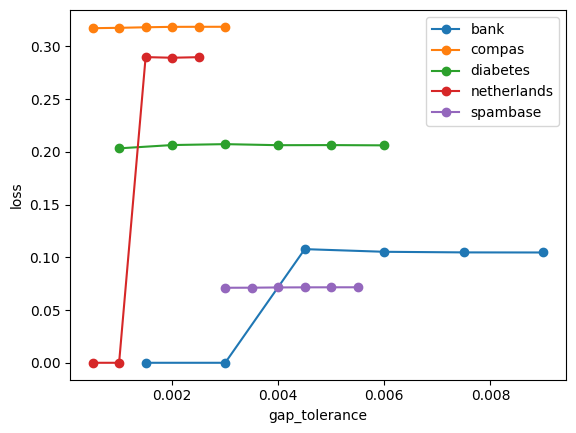

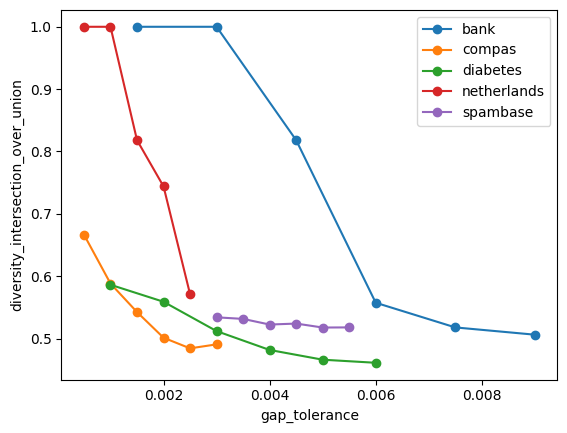

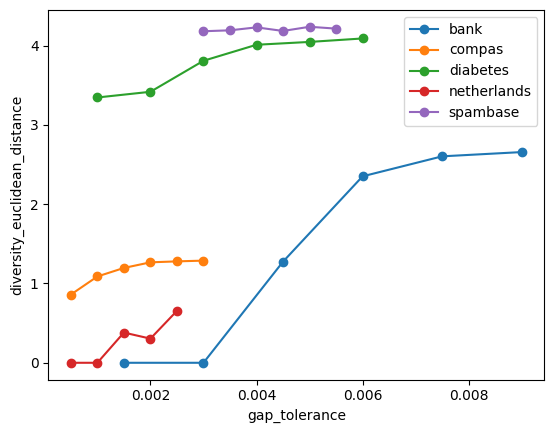

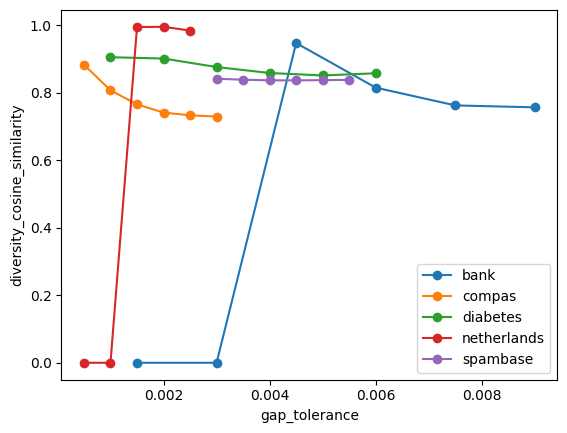

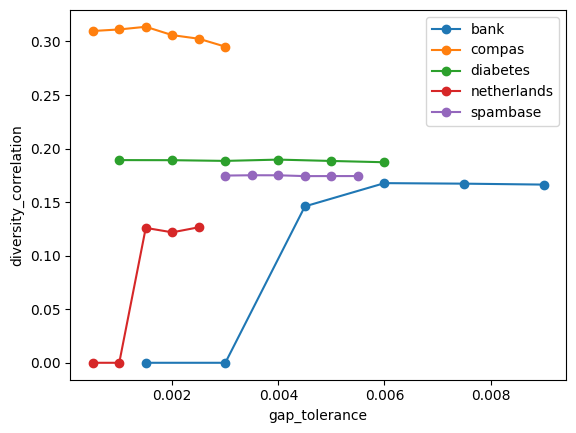

In [3]:
plot_gap_tolerance("tolerance_beam")

### Swaps

In [6]:
def plot_swaps(file_name):
    with open(f"results/{file_name}.pkl", "rb") as f:
        results = pickle.load(f)
    results = pd.DataFrame(results)
    swaps = []
    for rep in [9, 11, 13, 10]:
        swaps.extend([1] * rep + [2] * rep + [3] * rep + [4] * rep + [5] * rep)
    results["swaps"] = swaps

    has_solutions_results = results[results['num_solutions'] > 0]
    min_gap_results = has_solutions_results.loc[
        has_solutions_results.groupby(['dataset', 'swaps'])['gap_tolerance'].idxmin()
    ]
    plot_two_var(min_gap_results, "swaps", "gap_tolerance")
    plot_two_var(min_gap_results, "swaps", "runtime")
    plot_two_var(min_gap_results, "swaps", "num_solutions")
    for diversity_fnc in [intersection_over_union, euclidean_distance, cosine_similarity]:
        col_name = f"diversity_{diversity_fnc.__name__}"
        min_gap_results[col_name] = min_gap_results["betas"].apply(lambda betas: average_pairwise_diversity(betas, diversity_fnc, 50))
        plot_two_var(min_gap_results, "swaps", col_name)

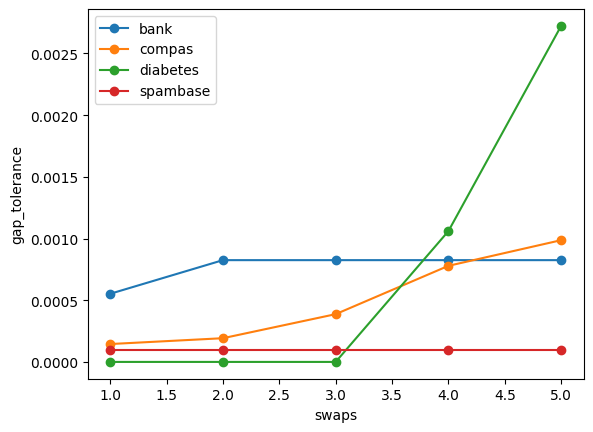

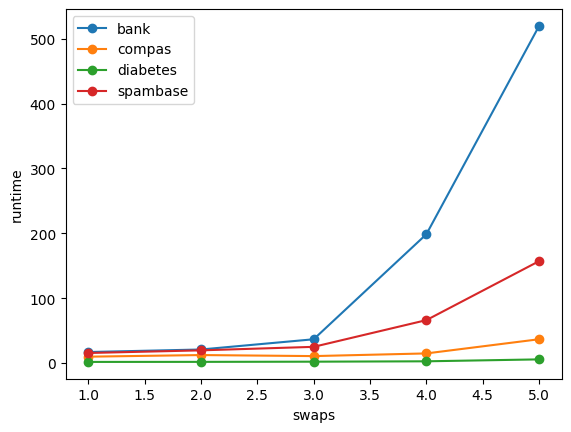

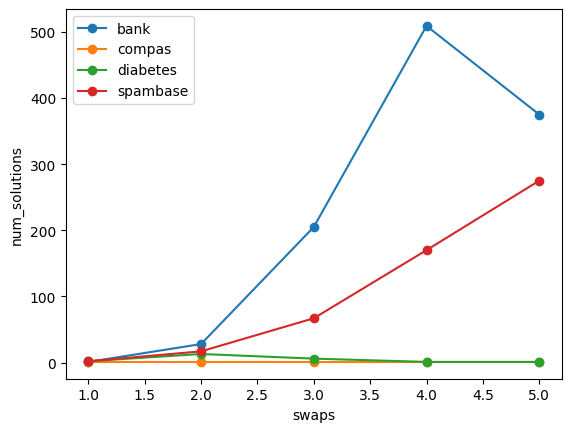

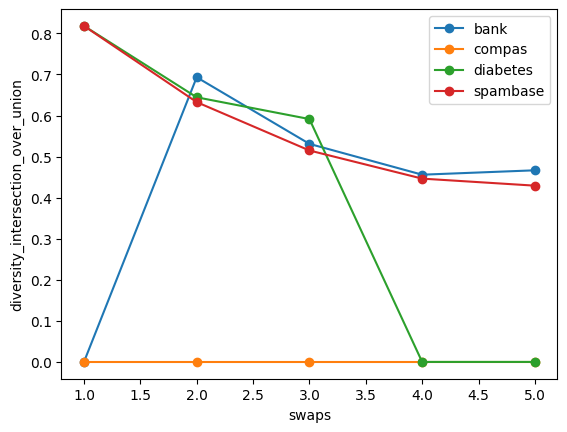

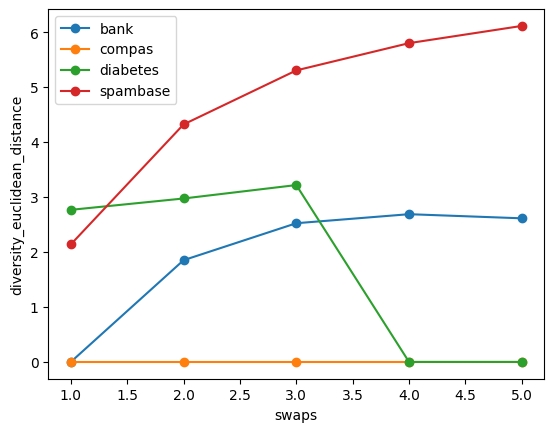

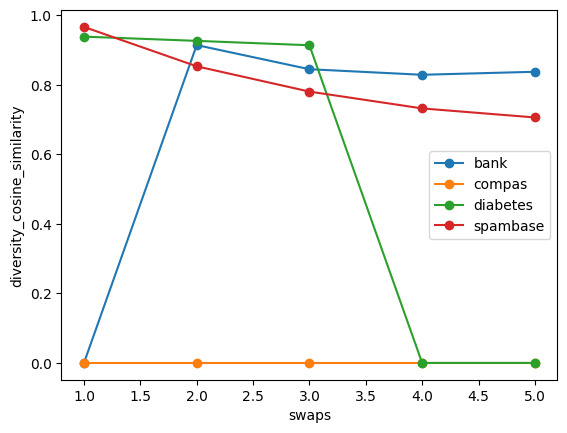

In [7]:
plot_swaps("swaps")

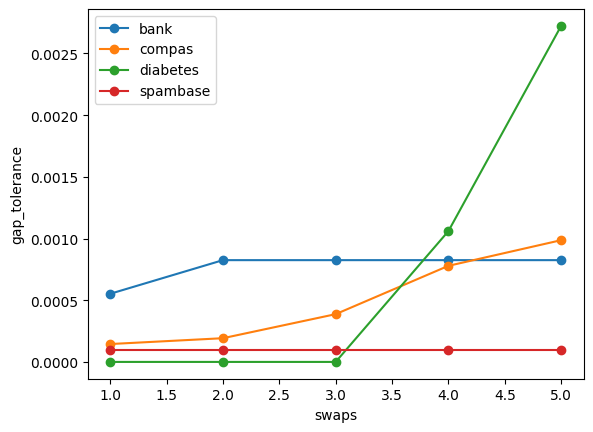

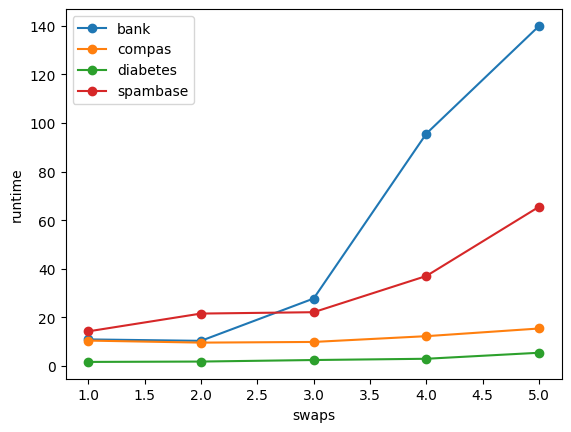

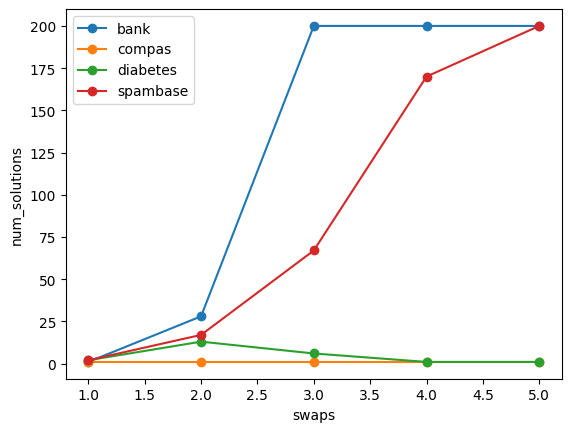

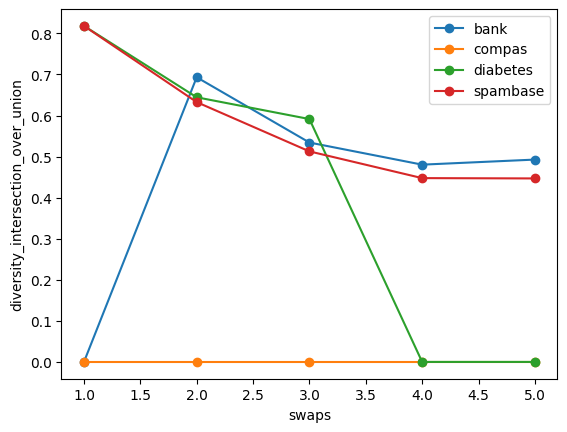

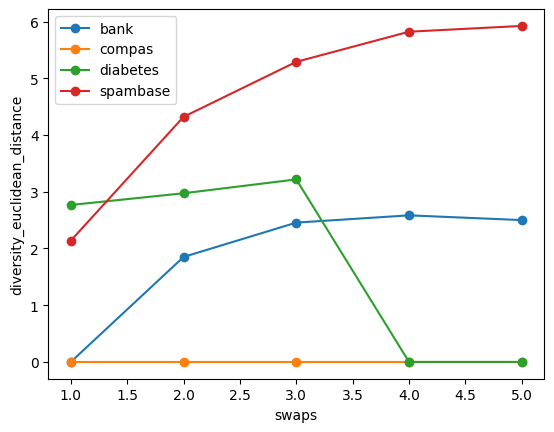

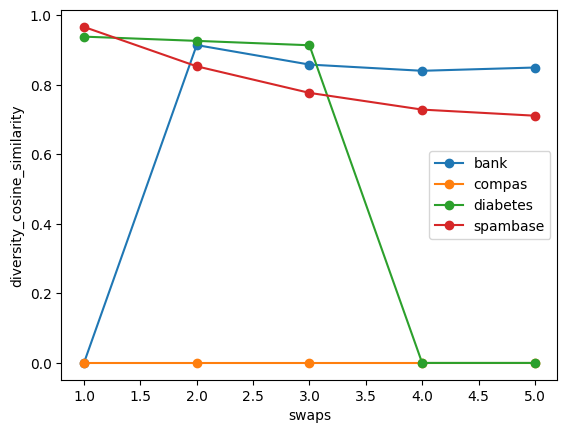

In [8]:
plot_swaps("swaps_beam")

### FineTuning

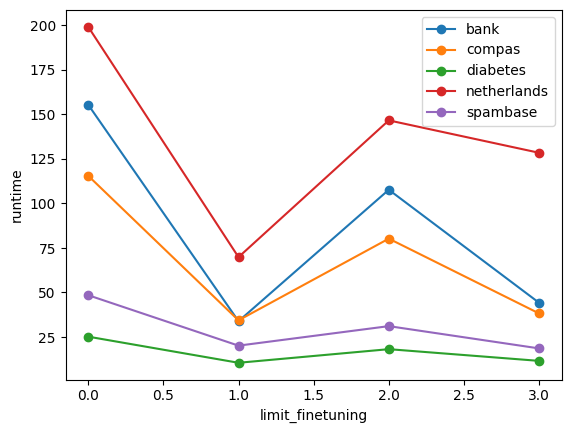

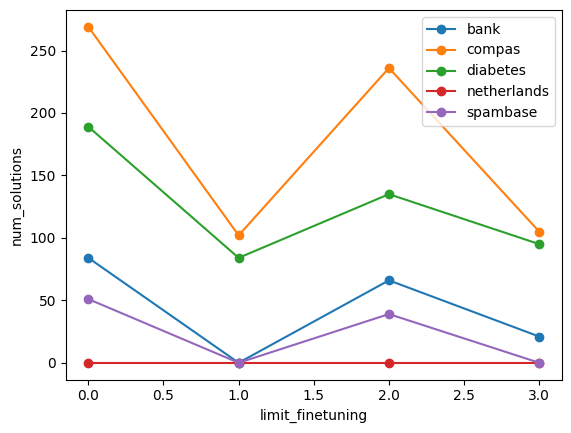

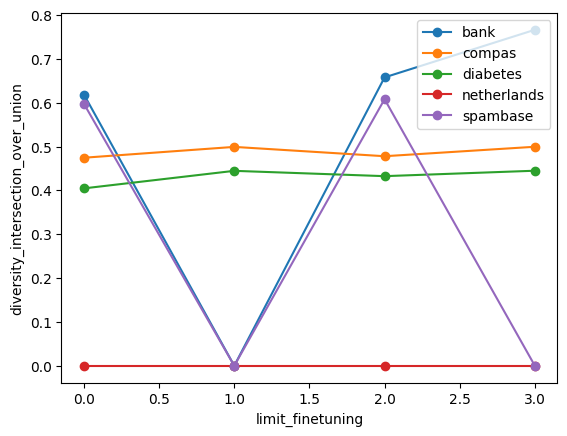

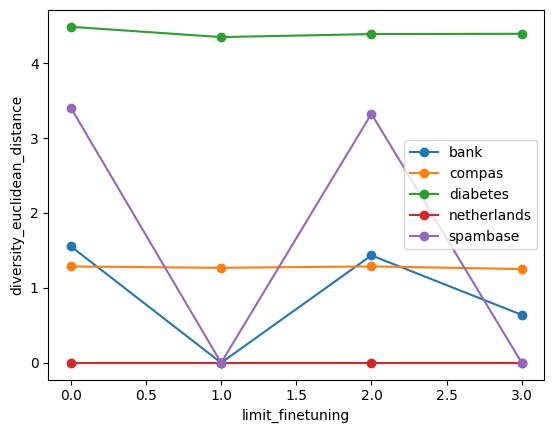

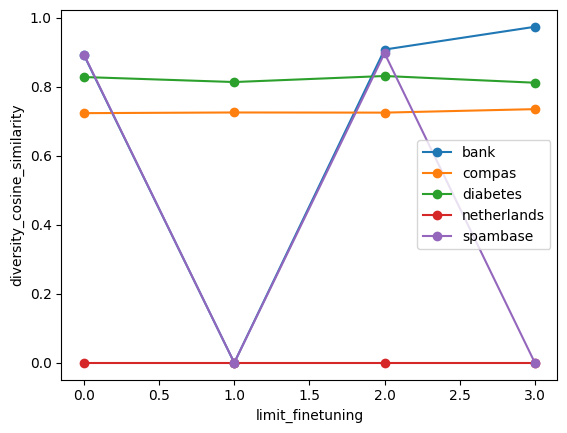

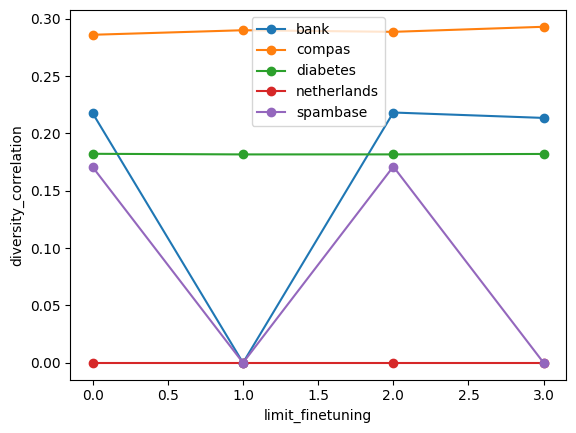

In [ ]:
with open(f"results/finetuning.pkl", "rb") as f:
    results = pickle.load(f)
results = pd.DataFrame(results)

plot_two_var(results, "limit_finetuning", "runtime")
plot_two_var(results, "limit_finetuning", "num_solutions")

for diversity_fnc in [intersection_over_union, euclidean_distance, cosine_similarity]:
    col_name = f"diversity_{diversity_fnc.__name__}"
    results[col_name] = results["betas"].apply(lambda betas: average_pairwise_diversity(betas, diversity_fnc, 50))
    plot_two_var(results, "limit_finetuning", col_name)
plot_diversity_correlation(results, "limit_finetuning")

### Extra

In [32]:
results.iloc[-1]

dataset                                                          spambase
dataset_shape                                                  (4601, 58)
num_estimators                                                         50
gap_tolerance                                                      0.0055
feature_selection                                                     top
threshold_guess_time                                             0.370117
num_features                                                           30
runtime                                                         50.479819
betas                   [[0.0, -1.2863523992307195, 0.0, -2.4292739762...
beta0                   [-2.9787833961451575, -2.8452782962596466, -2....
num_solutions                                                         102
loss                                                             0.071562
Name: 28, dtype: object

Dataset: bank
Binarized shape: (4521, 17)
swap 0
swap 1
swap 2
swap 3
swap 4
	0.01 tolerance, 84 solutions, 217.05 seconds


100%|██████████| 84/84 [00:00<00:00, 332.69it/s]


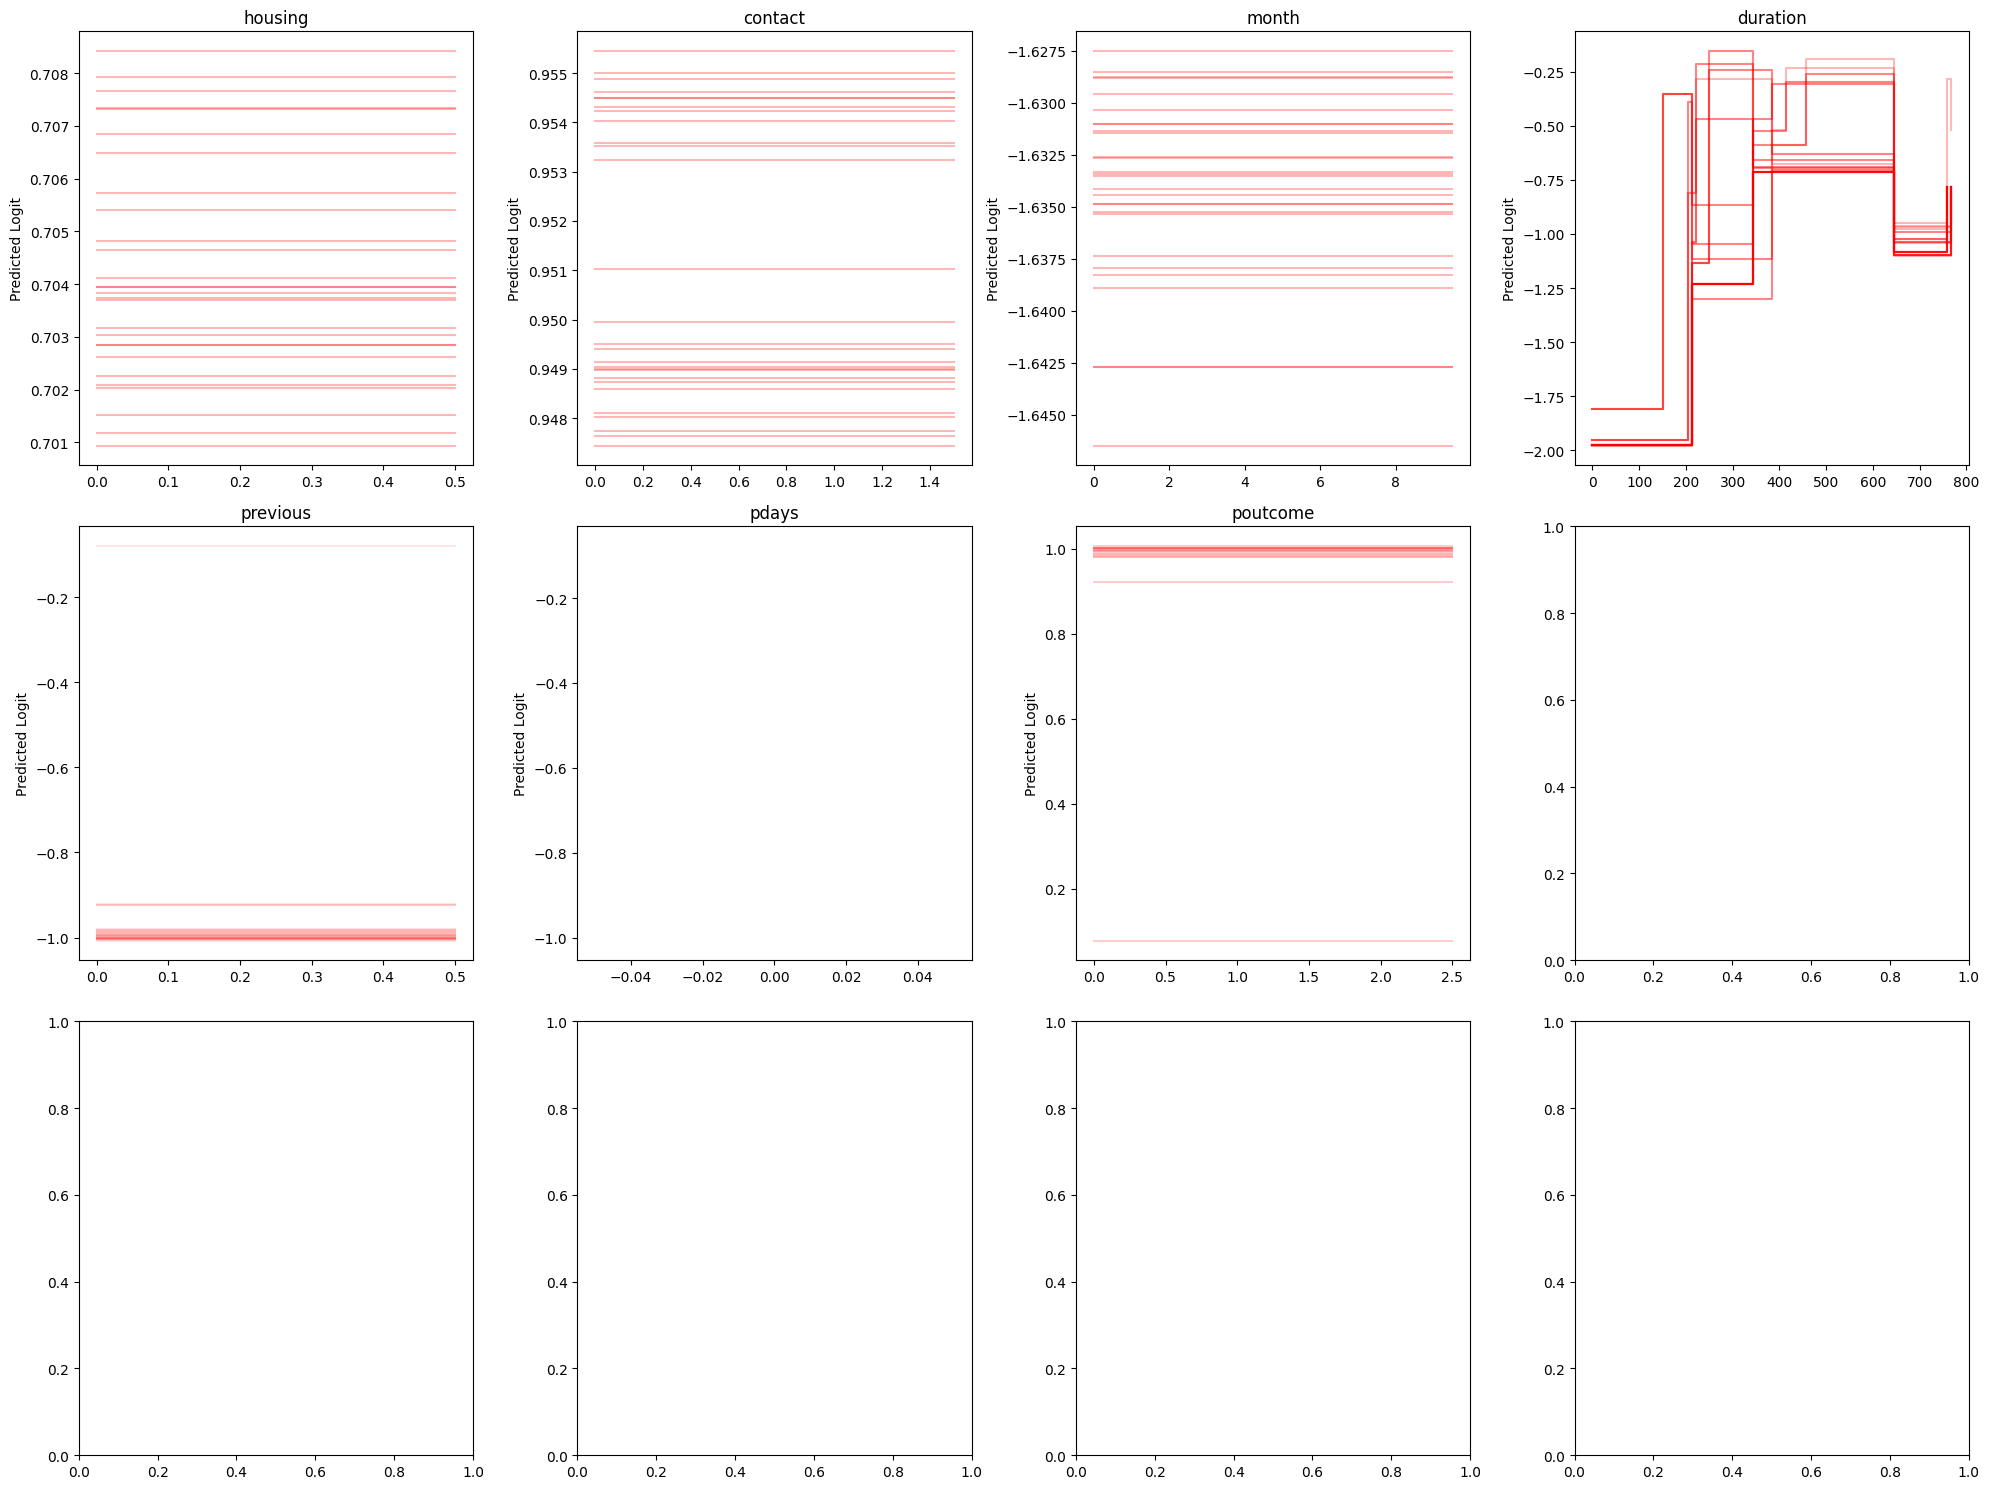

defaultdict(int,
            {'housing<=0.5': 84,
             'contact<=1.5': 84,
             'month<=9.5': 84,
             'duration<=90.5': 84,
             'duration<=212.5': 78,
             'duration<=343.5': 63,
             'duration<=414.5': 9,
             'duration<=645.5': 84,
             'duration<=766.5': 48,
             'previous<=0.5': 30,
             'pdays<=0.0': 30,
             'poutcome<=2.5': 30,
             'duration<=151.5': 12,
             'duration<=456.5': 9,
             'duration<=758.5': 39,
             'duration<=383.5': 27,
             'duration<=204.5': 12,
             'duration<=248.5': 12,
             'duration<=221.5': 15})

In [ ]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from FasterRisk.src.fasterrisk import fasterrisk
from time import time
import pickle

dataset_settings = {
    'bank': {
        'gap_tolerance': 0.01,
        'num_estimators': 50,
    },
}

for dataset_name, settings in dataset_settings.items():
    ne = settings["num_estimators"]
    gt = settings['gap_tolerance']

    path = '../datasets/{}.csv'.format(dataset_name)
    dataset = pd.read_csv(path)
    print(f"Dataset: {dataset_name}")
    print(f"Binarized shape: {dataset.shape}")

    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, ne)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]
    header = pd.Index(["intercept"] + list(X.columns)).astype("object")
    X_one_hot, y = utils.get_X_y(X, y)

    start = time()
    rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=gt, select_top_m=-1, maxAttempts=25)
    rs.optimize_with_swaps_beam_search(swaps=5, beam_size=1000)
    end = time()

    print(f"\t{gt} tolerance, {rs.sparseDiversePool_betas.shape[0]} solutions, {end - start:.2f} seconds")



betas, beta0 = rs.sparseDiversePool_betas, rs.sparseDiversePool_beta0

plot_gam(header, betas)

100%|██████████| 414/414 [00:00<00:00, 637.94it/s] 


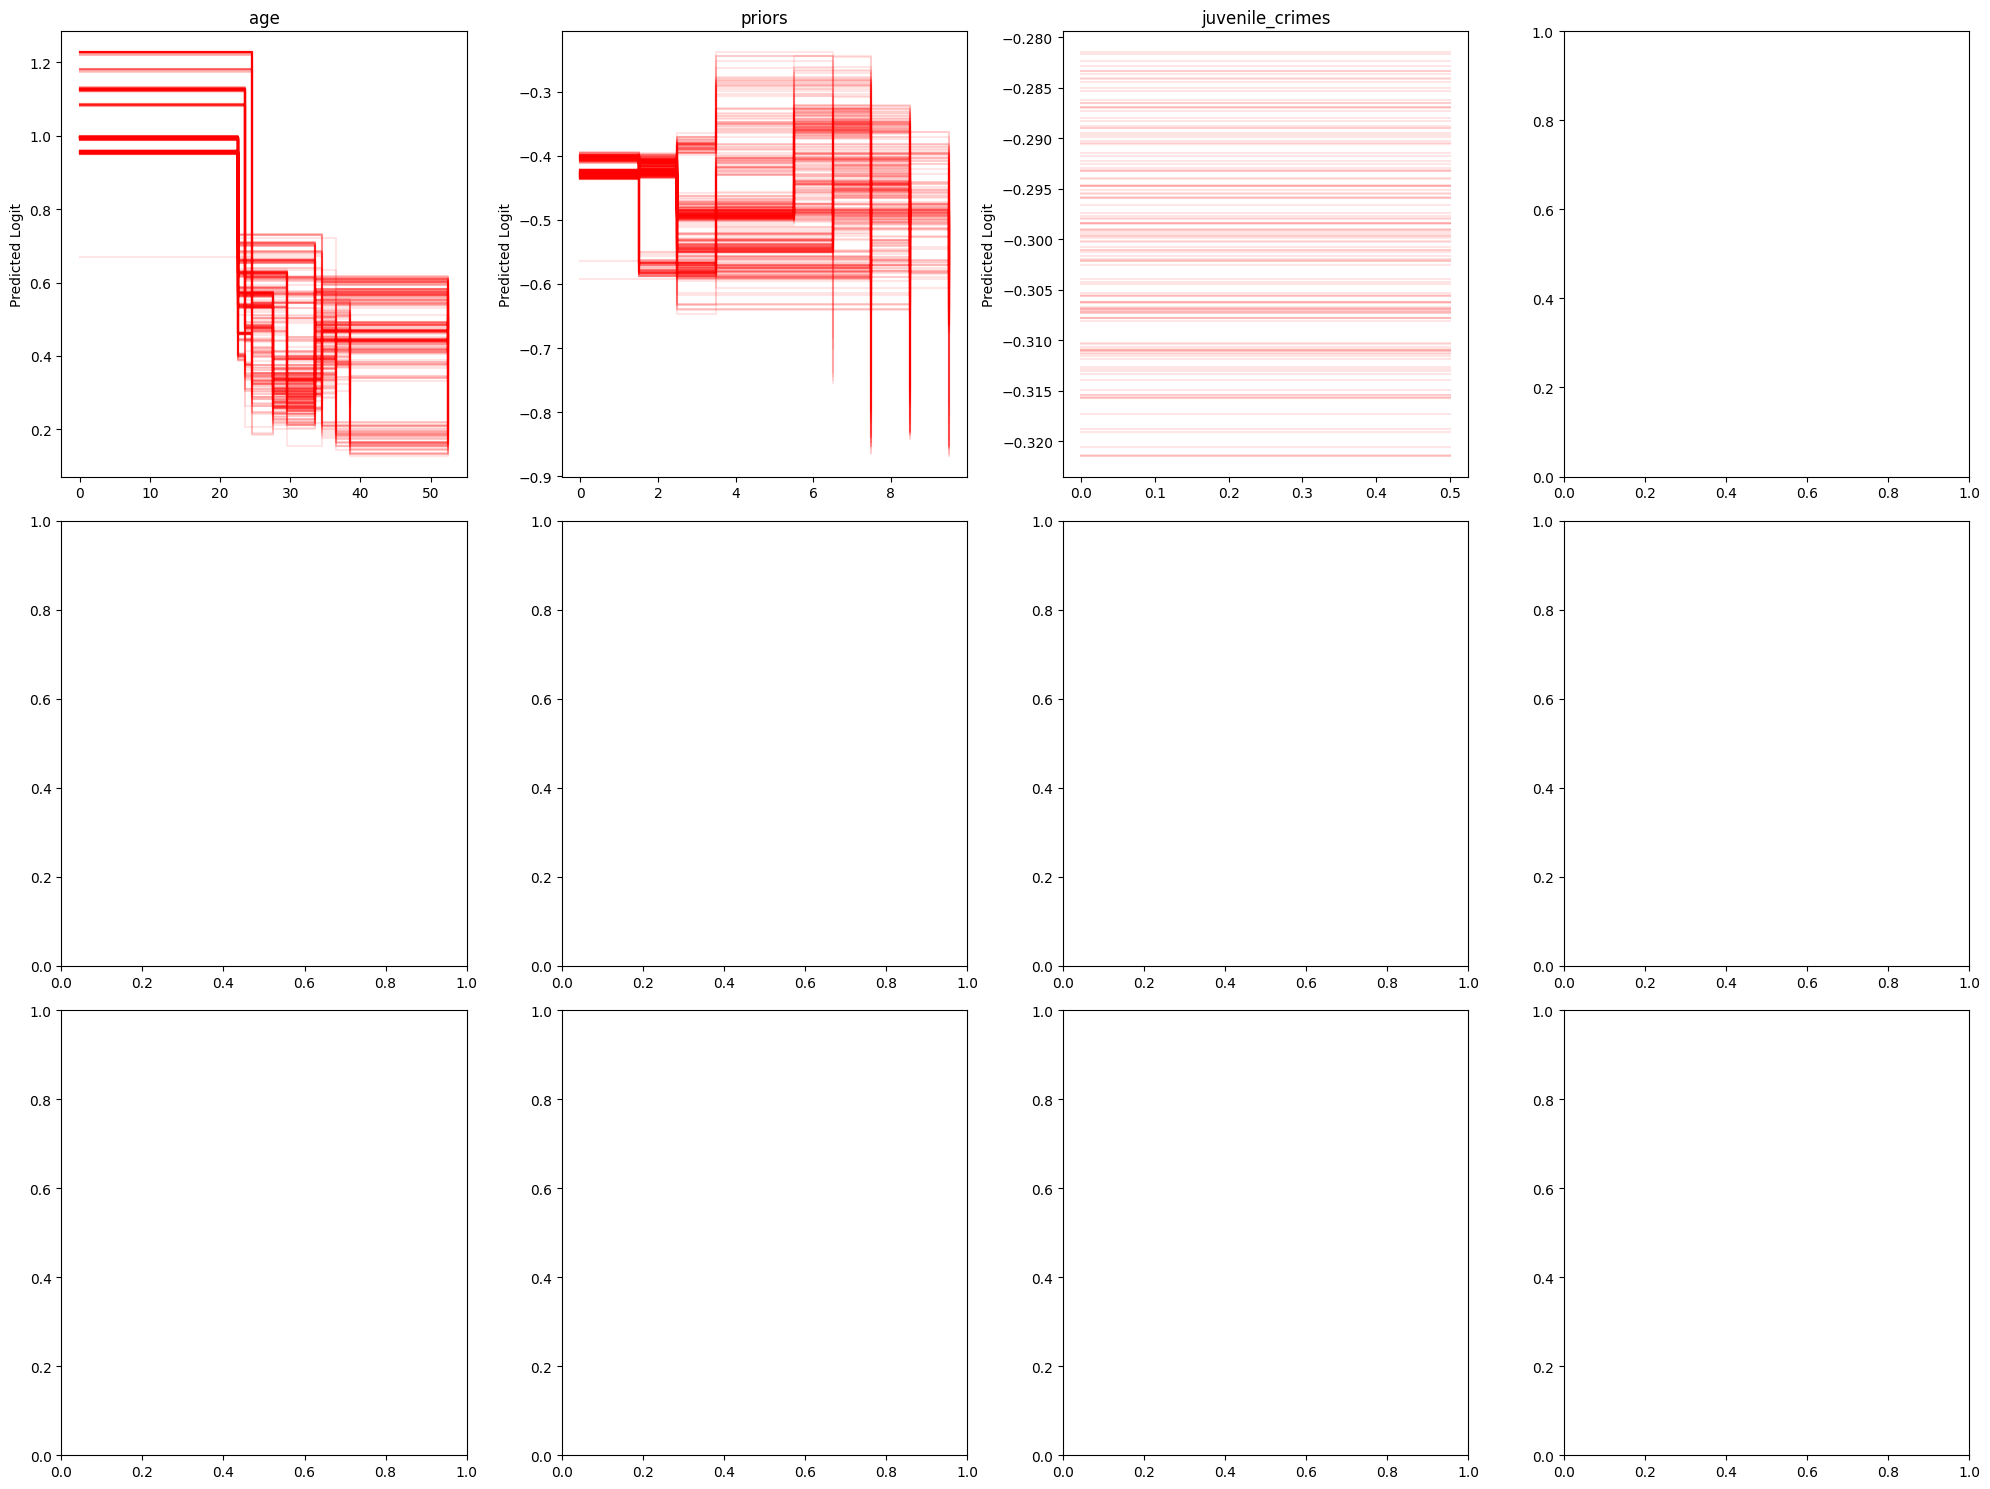

defaultdict(int,
            {'age<=20.5': 413,
             'age<=22.5': 268,
             'age<=27.5': 146,
             'age<=34.5': 121,
             'age<=52.5': 293,
             'priors_count<=0.5': 414,
             'priors_count<=1.5': 412,
             'priors_count<=2.5': 340,
             'priors_count<=6.5': 96,
             'priors_count<=9.5': 136,
             'age<=29.5': 84,
             'priors_count<=5.5': 184,
             'age<=23.5': 123,
             'age<=33.5': 242,
             'juvenile_crimes<=0.5': 134,
             'age<=24.5': 104,
             'priors_count<=7.5': 139,
             'age<=36.5': 96,
             'priors_count<=3.5': 133,
             'priors_count<=8.5': 186,
             'age<=38.5': 76})

In [4]:

with open(f"results/tolerance.pkl", "rb") as f:
    results = pickle.load(f)
results = pd.DataFrame(results)
# i = 5
i = 11
# i = 17
# i = 22
# i = -1

betas, beta0 = results.iloc[i]["betas"], results.iloc[i]["beta0"]
_, _, header = construct_dataset(results.iloc[i]["dataset"], results.iloc[i]["num_estimators"], results.iloc[i]["num_features"])

plot_gam(header, betas)
